### 本日進度  
* [Stock Chart Patterns Dataset](https://www.google.com/search?q=Stock+Chart+Patterns+Dataset)  
  - [foduucom/stockmarket-pattern-detection-yolov8](https://huggingface.co/foduucom/stockmarket-pattern-detection-yolov8)  
  - [Stock chart Computer Vision Project](https://www.google.com/search?q=Stock+Chart+Patterns+Dataset)  
* **程式開發**：型態辨識程序  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np
import myutils

In [2]:
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

In [3]:
from collections import defaultdict

# 原型版：初步開發
def chart_patterns_recognition_4point_prototype(turning_points, max_bars = 100):
    # 儲存型態實例
    patterns = defaultdict(list)
    
    #循環迭代轉折點數據
    # TODO : 問題待檢討 ： len(turning_points) → (len(turning_points)+1)
    for i in range(4, (len(turning_points)+1)):
        
        # 在變數window中一次儲存4個局部最小值和局部最大值點
        window = turning_points.iloc[i-4:i]
        
        # 型態必須在max_bars內發揮出來（預設為 100）
        if window.index[-1] - window.index[0] > max_bars:
            continue
        
        # 儲存4個獨特點以檢查條件
        e1      = window.iloc[0]['Price']
        e2      = window.iloc[1]['Price']
        e3      = window.iloc[2]['Price']
        e4      = window.iloc[3]['Price']
        rtop_g1 = np.mean([e1,e3])
        rtop_g2 = np.mean([e2,e4])
        
        if e2 > e1 and e4 > e3 and e3 > e1 and e4 > e2 and (e2 - e1) > (e4 - e3) and abs(((e4 - e3) - (e2 - e1)) / (e2 - e1)) > 0.25 :
            # 上升楔型
            patterns['RISE_WEDGE'].append(window)
        elif e1 > e2 and e3 > e4 and e1 > e3 and e2 > e4 and (e1 - e2) > (e3 - e4) and abs(((e3 - e4) - (e1 - e2)) / (e1 - e2)) > 0.25 :
            # 下降楔型
            patterns['FALL_WEDGE'].append(window)
        elif (e1 > e2) and (abs(e1-rtop_g1)/rtop_g1 < 0.0075) and (abs(e3-rtop_g1)/rtop_g1 < 0.0075) and \
            (abs(e2-rtop_g2)/rtop_g2 < 0.0075) and (abs(e4-rtop_g2)/rtop_g2 < 0.0075) and (min(e1, e3) > max(e2, e4)):
            # 矩形
            patterns['RECT'].append(window)
        elif e1 < e3 and e3 < e2 and e3 < e4 and \
            (abs(e2-rtop_g2)/rtop_g2 < 0.03) and (abs(e4-rtop_g2)/rtop_g2 < 0.03) :
            # 雙重頂
            patterns['DOUBLE_TOP'].append(window)
        elif e1 > e3 and e3 > e2 and e3 > e4 and \
            (abs(e2-rtop_g2)/rtop_g2 < 0.03) and (abs(e4-rtop_g2)/rtop_g2 < 0.03) :
            # 雙重底
            patterns['DOUBLE_BOTTOM'].append(window)    
        
    return patterns

# 原型版：初步開發
def chart_patterns_recognition_5point_prototype(turning_points, max_bars = 100):
    # 儲存型態實例
    patterns = defaultdict(list)
    
    #循環迭代轉折點數據
    # TODO : 問題待檢討 ： len(turning_points) → (len(turning_points)+1)    
    for i in range(5, len(turning_points)+1):
        
        # 在變數window中一次儲存5個局部最小值和局部最大值點
        window = turning_points.iloc[i-5:i]
        
        # 型態必須在max_bars內發揮出來（預設為 100）
        if window.index[-1] - window.index[0] > max_bars:
            continue
        
        # 儲存5個獨特點以檢查條件
        e1      = window.iloc[0]['Price']
        e2      = window.iloc[1]['Price']
        e3      = window.iloc[2]['Price']
        e4      = window.iloc[3]['Price']
        e5      = window.iloc[4]['Price']

        if (e1 > e2) and (e1 > e3) and (e3 > e5) and (e2 < e4):
            # 三角形
            patterns['TRIG'].append(window)
        else :
            # 其他型態
            pass

    return patterns

# 原型版：初步開發
def chart_patterns_recognition_6point_prototype(turning_points, max_bars = 100):
    # 儲存型態實例
    patterns = defaultdict(list)
    
    #循環迭代轉折點數據
    # TODO : 問題待檢討 ： len(turning_points) → (len(turning_points)+1)    
    for i in range(6, len(turning_points)+1):
        
        # 在變數window中一次儲存6個局部最小值和局部最大值點
        window = turning_points.iloc[i-6:i]
        
        # 型態必須在max_bars內發揮出來（預設為 100）
        if window.index[-1] - window.index[0] > max_bars:
            continue
        
        # 儲存6個獨特點以檢查條件
        e1      = window.iloc[0]['Price']
        e2      = window.iloc[1]['Price']
        e3      = window.iloc[2]['Price']
        e4      = window.iloc[3]['Price']
        e5      = window.iloc[4]['Price']
        e6      = window.iloc[5]['Price']

        if (e3 < e1) and (e5 < e1) and (e2 < e3) and (e4 < e2) and (e4 < e6) and \
            (abs(e3-e5) <= np.mean([e3,e5])*0.05) :
            # TODO : 判斷條件待確認，參照：https://ithelp.ithome.com.tw/articles/10317498
            # 頭肩底
            patterns['IHS'].append(window)
        elif (e3 > e1) and (e5 > e1) and (e2 > e3) and (e4 > e2) and (e4 > e6) and \
            (abs(e3-e5) <= np.mean([e3,e5])*0.05) :
            # 頭肩頂
            patterns['HS'].append(window)
        else :
            # 其他型態
            pass
    
    return patterns

In [4]:
##### 使用2018年2月2日到2018年8月27日之日線圖資料 #####

# NOTE ： 資料來自「型態理論」講義

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_3702_250222.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

轉折點總筆數 ＝ 5


,Date,Price,Type
DateIndex,,,
5,2018-02-09,36.15,LO
78,2018-06-06,44.30,HI
99,2018-07-06,42.85,LO
108,2018-07-19,44.25,HI
133,2018-08-23,38.10,LO


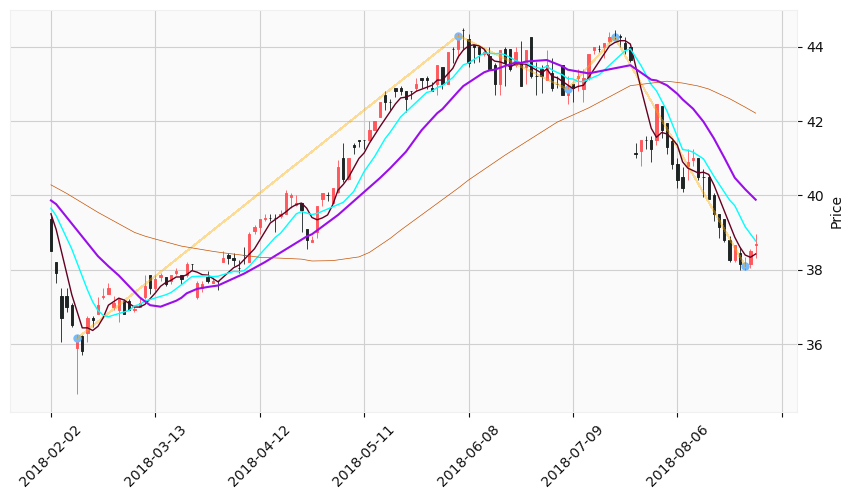

In [5]:
turning_points = myutils.test_DetectTurningPoints(df_k_line,df_sma,'close',order=10,smoothing=3)

defaultdict(<class 'list'>, {'DOUBLE_TOP': [                Date  Price Type
DateIndex                       
5         2018-02-09  36.15   LO
78        2018-06-06  44.30   HI
99        2018-07-06  42.85   LO
108       2018-07-19  44.25   HI]})


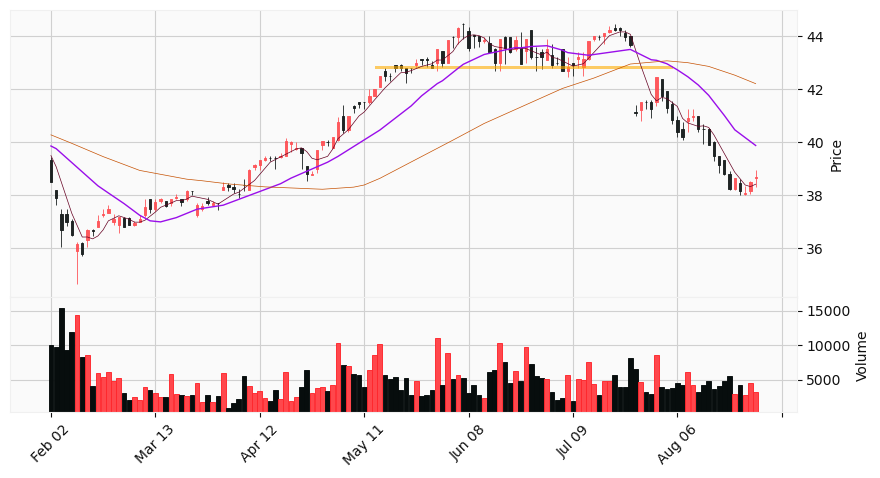

In [6]:
patterns = chart_patterns_recognition_4point_prototype(turning_points,max_bars=240)
print(patterns)
pattern = patterns['DOUBLE_TOP'][-1]

neckline_start_date = '2018-05-15'
neckline_end_date   = '2018-08-03'
neckline_start_price = pattern.iloc[2]['Price']
neckline_end_price   = pattern.iloc[2]['Price']

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]]

# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.5,color='xkcd:maroon'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=1.0,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(df_sma['SMA60'],width=0.5,color='xkcd:dark orange')
            }

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True,addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:orange yellow', alpha=0.6), warn_too_much_data=1100)
mpf.plot(df_k_line,**kwargs)

In [7]:
##### 使用2020年5月29日到2021年1月20日之日線圖資料 #####

# NOTE ： 資料來自「型態理論」講義

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_3526_250222.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

轉折點總筆數 ＝ 11


,Date,Price,Type
DateIndex,,,
2,2020-06-02,99.2,HI
10,2020-06-12,90.0,LO
25,2020-07-07,95.6,HI
40,2020-07-28,81.6,LO
47,2020-08-06,91.5,HI
58,2020-08-21,85.6,LO
66,2020-09-02,88.8,HI
105,2020-10-30,76.6,LO
127,2020-12-01,85.4,HI


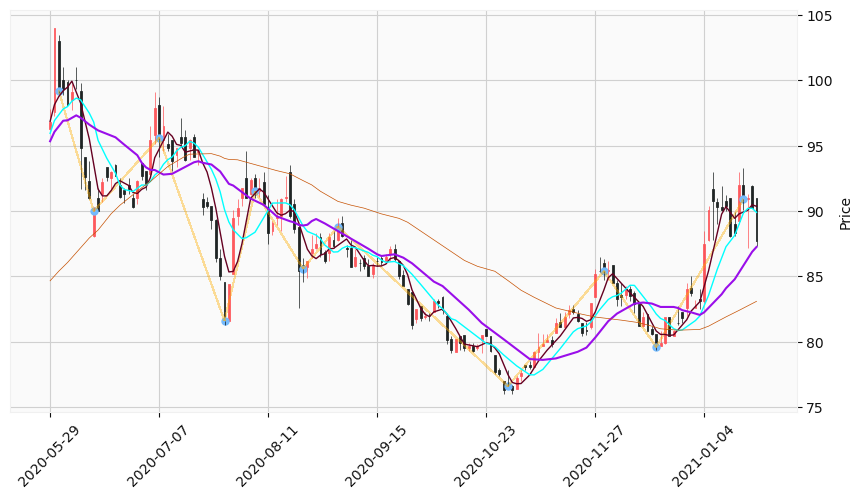

In [8]:
turning_points = myutils.test_DetectTurningPoints(df_k_line,df_sma,'close',order=10,smoothing=3)

defaultdict(<class 'list'>, {'DOUBLE_BOTTOM': [                Date  Price Type
DateIndex                       
25        2020-07-07   95.6   HI
40        2020-07-28   81.6   LO
47        2020-08-06   91.5   HI
58        2020-08-21   85.6   LO,                 Date  Price Type
DateIndex                       
66        2020-09-02   88.8   HI
105       2020-10-30   76.6   LO
127       2020-12-01   85.4   HI
139       2020-12-17   79.6   LO], 'DOUBLE_TOP': [                Date  Price Type
DateIndex                       
40        2020-07-28   81.6   LO
47        2020-08-06   91.5   HI
58        2020-08-21   85.6   LO
66        2020-09-02   88.8   HI]})


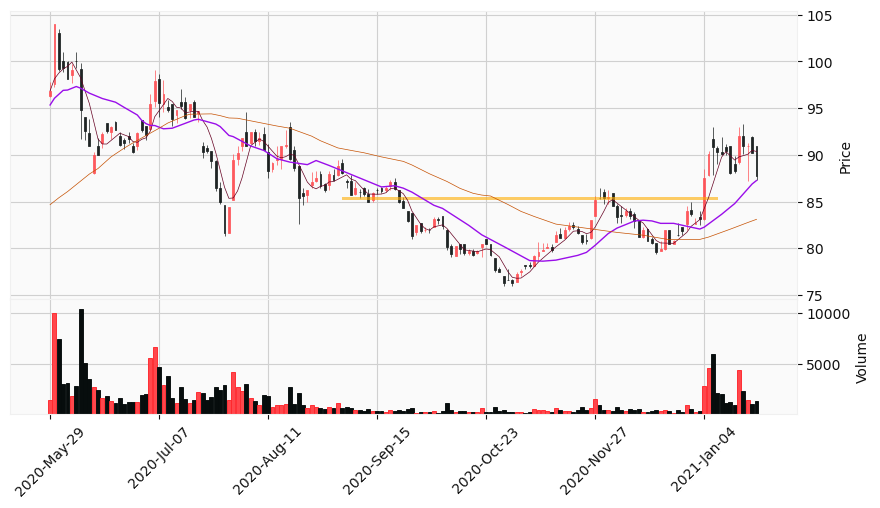

In [9]:
patterns = chart_patterns_recognition_4point_prototype(turning_points,max_bars=240)
print(patterns)
pattern = patterns['DOUBLE_BOTTOM'][-1]

neckline_start_date = '2020-09-03'
neckline_end_date   = '2021-01-07'
neckline_start_price = pattern.iloc[2]['Price']
neckline_end_price   = pattern.iloc[2]['Price']

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)]]

# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.5,color='xkcd:maroon'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=1.0,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(df_sma['SMA60'],width=0.5,color='xkcd:dark orange')
            }

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True,addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:orange yellow', alpha=0.6), warn_too_much_data=1100)
mpf.plot(df_k_line,**kwargs)